Dataset Shape: (6000, 5)
TF-IDF: (6000, 100)
States: 5
Actions: [np.int64(0), np.int64(1)]

Reward Matrix:
[[ 0.95585739 -0.95585739]
 [ 0.25974026 -0.25974026]
 [-0.82820785  0.82820785]
 [-0.28813559  0.28813559]
 [ 0.56947162 -0.56947162]]

Transition Matrix Shape: (5, 2, 5)
Converged after 84 iterations

VALUE ITERATION RESULTS
State 0: Value = 6.4060, Optimal Action = 0
State 1: Value = 5.7099, Optimal Action = 0
State 2: Value = 6.2783, Optimal Action = 1
State 3: Value = 5.7383, Optimal Action = 1
State 4: Value = 6.0196, Optimal Action = 0

MDP Accuracy: 0.8028333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81      3000
           1       0.83      0.76      0.80      3000

    accuracy                           0.80      6000
   macro avg       0.80      0.80      0.80      6000
weighted avg       0.80      0.80      0.80      6000


Confusion Matrix:
[[2523  477]
 [ 706 2294]]


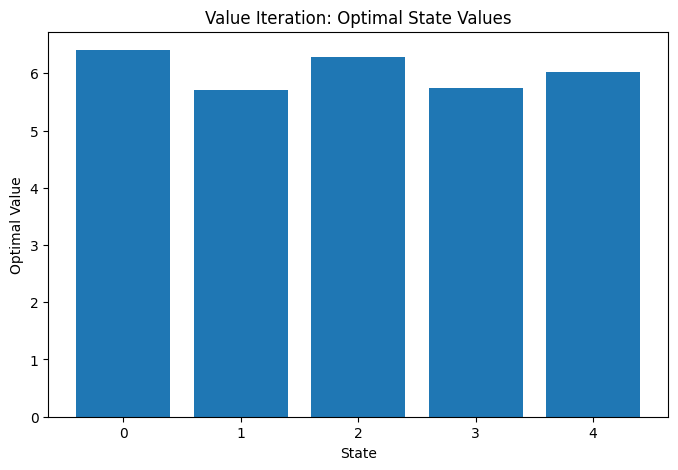

In [1]:
# ==========================================================
# MDP + BELLMAN EQUATION + VALUE ITERATION
# NEWS DATASET
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. LOAD DATA
# ==========================================================

df = pd.read_csv(
    "Data/news_dataset.csv"
)

print("Dataset Shape:", df.shape)

# ==========================================================
# 2. COMBINE NEWS TEXT
# ==========================================================

df["combined_text"] = (
    df["title"].fillna("") + " " +
    df["text"].fillna("") + " " +
    df["subject"].fillna("")
)

# ==========================================================
# 3. TF-IDF
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=100,
    stop_words="english"
)

X = vectorizer.fit_transform(
    df["combined_text"]
)

print("TF-IDF:", X.shape)

# ==========================================================
# 4. CREATE STATES USING K-MEANS
# ==========================================================

from sklearn.cluster import KMeans

num_states = 5

kmeans = KMeans(
    n_clusters=num_states,
    random_state=42,
    n_init=10
)

df["state"] = kmeans.fit_predict(X)

# ==========================================================
# 5. ACTIONS
# ==========================================================

unique_labels = sorted(
    df["label"].unique()
)

num_actions = len(unique_labels)

print("States:", num_states)
print("Actions:", unique_labels)

# ==========================================================
# 6. REWARD MATRIX
# ==========================================================

reward_matrix = np.zeros(
    (num_states, num_actions)
)

for state in range(num_states):

    state_data = df[
        df["state"] == state
    ]

    for action_index, action in enumerate(
        unique_labels
    ):

        if len(state_data) == 0:

            reward_matrix[
                state,
                action_index
            ] = 0

        else:

            correct_probability = (
                state_data["label"] == action
            ).mean()

            reward_matrix[
                state,
                action_index
            ] = (
                correct_probability * 1
                +
                (1 - correct_probability) * -1
            )

print("\nReward Matrix:")
print(reward_matrix)

# ==========================================================
# 7. TRANSITION MATRIX
# ==========================================================

state_counts = (
    df["state"]
    .value_counts()
    .sort_index()
)

state_probabilities = (
    state_counts /
    state_counts.sum()
).values

transition_matrix = np.zeros(
    (
        num_states,
        num_actions,
        num_states
    )
)

for state in range(num_states):

    for action in range(num_actions):

        transition_matrix[
            state,
            action,
            :
        ] = state_probabilities

print(
    "\nTransition Matrix Shape:",
    transition_matrix.shape
)

# ==========================================================
# 8. BELLMAN EQUATION
# ==========================================================

gamma = 0.9

def bellman_update(
    state,
    values
):

    action_values = []

    for action in range(num_actions):

        future_value = np.sum(
            transition_matrix[
                state,
                action,
                :
            ] * values
        )

        q_value = (
            reward_matrix[
                state,
                action
            ]
            +
            gamma * future_value
        )

        action_values.append(
            q_value
        )

    return max(action_values)

# ==========================================================
# 9. VALUE ITERATION
# ==========================================================

def value_iteration(
    gamma=0.9,
    theta=0.0001,
    max_iterations=1000
):

    values = np.zeros(
        num_states
    )

    for iteration in range(
        max_iterations
    ):

        new_values = np.zeros(
            num_states
        )

        delta = 0

        for state in range(
            num_states
        ):

            action_values = []

            for action in range(
                num_actions
            ):

                future_value = np.sum(
                    transition_matrix[
                        state,
                        action,
                        :
                    ] * values
                )

                q_value = (
                    reward_matrix[
                        state,
                        action
                    ]
                    +
                    gamma * future_value
                )

                action_values.append(
                    q_value
                )

            new_values[state] = max(
                action_values
            )

            delta = max(
                delta,
                abs(
                    new_values[state]
                    -
                    values[state]
                )
            )

        values = new_values

        if delta < theta:

            print(
                "Converged after",
                iteration + 1,
                "iterations"
            )

            break

    # ======================================================
    # EXTRACT POLICY
    # ======================================================

    policy = np.zeros(
        num_states,
        dtype=int
    )

    for state in range(
        num_states
    ):

        action_values = []

        for action in range(
            num_actions
        ):

            future_value = np.sum(
                transition_matrix[
                    state,
                    action,
                    :
                ] * values
            )

            q_value = (
                reward_matrix[
                    state,
                    action
                ]
                +
                gamma * future_value
            )

            action_values.append(
                q_value
            )

        policy[state] = np.argmax(
            action_values
        )

    return values, policy


# ==========================================================
# 10. RUN VALUE ITERATION
# ==========================================================

optimal_values, optimal_policy = (
    value_iteration()
)

# ==========================================================
# 11. RESULTS
# ==========================================================

print("\n====================================")
print("VALUE ITERATION RESULTS")
print("====================================")

for state in range(
    num_states
):

    print(
        f"State {state}: "
        f"Value = "
        f"{optimal_values[state]:.4f}, "
        f"Optimal Action = "
        f"{optimal_policy[state]}"
    )

# ==========================================================
# 12. APPLY POLICY
# ==========================================================

policy_mapping = dict(
    zip(
        range(num_states),
        optimal_policy
    )
)

df["predicted_label_MDP"] = (
    df["state"].map(
        policy_mapping
    )
)

# ==========================================================
# 13. EVALUATION
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    df["label"],
    df["predicted_label_MDP"]
)

print(
    "\nMDP Accuracy:",
    accuracy
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        df["label"],
        df["predicted_label_MDP"]
    )
)

# ==========================================================
# 14. CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    df["label"],
    df["predicted_label_MDP"]
)

print(
    "\nConfusion Matrix:"
)

print(cm)

# ==========================================================
# 15. VISUALIZE STATE VALUES
# ==========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    range(num_states),
    optimal_values
)

plt.xlabel("State")
plt.ylabel("Optimal Value")

plt.title(
    "Value Iteration: Optimal State Values"
)

plt.xticks(
    range(num_states)
)

plt.show()

In [2]:
import numpy as np
import random

# Grid size
rows = 4
cols = 4

# Actions
# 0 = Up
# 1 = Down
# 2 = Left
# 3 = Right
actions = [0, 1, 2, 3]

# Start and goal
start = (0, 0)
goal = (3, 3)

# Learning parameters
alpha = 0.1
gamma = 0.9
epsilon = 0.1

# Q-table
Q = np.zeros((rows, cols, len(actions)))

In [3]:
def get_next_state(state, action):

    row, col = state

    if action == 0:       # Up
        row = max(0, row - 1)

    elif action == 1:     # Down
        row = min(rows - 1, row + 1)

    elif action == 2:     # Left
        col = max(0, col - 1)

    elif action == 3:     # Right
        col = min(cols - 1, col + 1)

    return (row, col)

In [4]:
def get_reward(state):

    if state == goal:
        return 10

    return -1

In [5]:
Q_learning = np.zeros((rows, cols, len(actions)))

episodes = 1000

for episode in range(episodes):

    state = start

    while state != goal:

        # Epsilon-greedy action selection
        if random.random() < epsilon:
            action = random.choice(actions)
        else:
            action = np.argmax(Q_learning[state[0], state[1]])

        # Take action
        next_state = get_next_state(state, action)

        # Get reward
        reward = get_reward(next_state)

        # Q-Learning update
        best_next_q = np.max(
            Q_learning[next_state[0], next_state[1]]
        )

        Q_learning[state[0], state[1], action] += alpha * (
            reward
            + gamma * best_next_q
            - Q_learning[state[0], state[1], action]
        )

        state = next_state

print("Q-Learning completed.")

Q-Learning completed.


In [6]:
Q_sarsa = np.zeros((rows, cols, len(actions)))

episodes = 1000

for episode in range(episodes):

    state = start

    # Select first action
    if random.random() < epsilon:
        action = random.choice(actions)
    else:
        action = np.argmax(Q_sarsa[state[0], state[1]])

    while state != goal:

        # Take action
        next_state = get_next_state(state, action)

        # Reward
        reward = get_reward(next_state)

        # Select next action
        if random.random() < epsilon:
            next_action = random.choice(actions)
        else:
            next_action = np.argmax(
                Q_sarsa[next_state[0], next_state[1]]
            )

        # SARSA update
        Q_sarsa[state[0], state[1], action] += alpha * (
            reward
            + gamma * Q_sarsa[
                next_state[0],
                next_state[1],
                next_action
            ]
            - Q_sarsa[state[0], state[1], action]
        )

        state = next_state
        action = next_action

print("SARSA completed.")

SARSA completed.


In [7]:
symbols = {
    0: "↑",
    1: "↓",
    2: "←",
    3: "→"
}

print("Q-Learning Policy")

for i in range(rows):
    for j in range(cols):

        if (i, j) == goal:
            print("G", end=" ")
        else:
            best_action = np.argmax(Q_learning[i, j])
            print(symbols[best_action], end=" ")

    print()

Q-Learning Policy
↓ ↓ ↓ ↓ 
→ ↓ ↓ ↓ 
→ → → ↓ 
→ → → G 


In [8]:
print("SARSA Policy")

for i in range(rows):
    for j in range(cols):

        if (i, j) == goal:
            print("G", end=" ")
        else:
            best_action = np.argmax(Q_sarsa[i, j])
            print(symbols[best_action], end=" ")

    print()

SARSA Policy
→ ↓ ↓ ↓ 
→ → ↓ ↓ 
→ → → ↓ 
↑ → → G 
